# Проверка ML после экспертной сессии Q&A

Обучение — январь–август, проверка — сентябрь–октябрь 2025.
Маршрут №5 исключён из обучения и метрик; нули сохранены только в конкурсном CSV.
Технологические часы 01–04 занулены, час 05 сохранён.
Старый выпуск и его сабмит не заменены. Этот ноутбук воспроизводится по агрегатам без raw.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.figure import Figure

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "ml/reports").is_dir())
REPORTS = ROOT / "ml/reports"
FIGURES = ROOT / "ml/reports/figures"
FIGURES.mkdir(parents=True, exist_ok=True)
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
        "figure.figsize": (11, 5),
        "axes.grid": True,
        "grid.alpha": 0.18,
        "axes.axisbelow": True,
        "figure.facecolor": "white",
        "savefig.facecolor": "white",
    }
)
BLUE, TEAL, ORANGE = "#234E70", "#008A85", "#D57433"


def finish(fig: Figure, name: str) -> None:
    fig.tight_layout()
    fig.savefig(FIGURES / f"{name}.png", dpi=160, bbox_inches="tight")
    display(fig)
    plt.close(fig)

In [2]:
metrics = json.loads((REPORTS / "qna/metrics.json").read_text(encoding="utf-8"))
comparison = json.loads((REPORTS / "qna/comparison.json").read_text(encoding="utf-8"))
data = pd.read_csv(REPORTS / "qna/validation.csv", sep=";", parse_dates=["date"])
assert len(data) == 13176 and 5 not in set(data.route)
assert not data.duplicated(["route", "date", "hour"]).any()
assert data.loc[data.hour.between(1, 4), ["boardings", "prediction"]].eq(0).all().all()
assert data.loc[data.hour.eq(5), "boardings"].equals(data.loc[data.hour.eq(5), "raw_boardings"])
for column, key in [
    ("boardings", "validation_clean_target"),
    ("raw_boardings", "validation_original_labels"),
]:
    score = 1 - (data[column] - data.prediction).abs().sum() / data[column].sum()
    assert np.isclose(score, metrics[key]["wape_score"], atol=1e-12, rtol=0)
display(
    pd.DataFrame(
        {k: metrics[k] for k in ["validation_clean_target", "validation_original_labels"]}
    ).T
)

,mae,wape_score
validation_clean_target,104.243245,0.892271
validation_original_labels,104.610276,0.891932


## 1. Изменение качества при одинаковом определении цели

Нельзя сравнивать новую очищенную метрику со старой метрикой на необработанных labels.
Поэтому обе модели сопоставлены на каждом из двух определений цели.
Период использовался при разработке и не является новым независимым тестом.

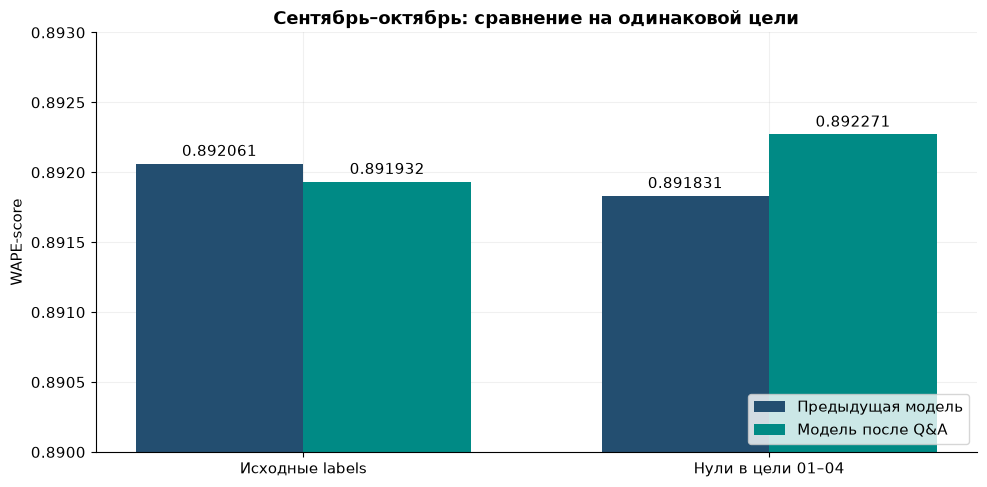

In [3]:
labels = ["Исходные labels", "Нули в цели 01–04"]
old = [comparison["old_model_original_labels_score"], comparison["old_model_clean_target_score"]]
new = [
    metrics["validation_original_labels"]["wape_score"],
    metrics["validation_clean_target"]["wape_score"],
]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(2)
first = ax.bar(x - 0.18, old, width=0.36, color=BLUE, label="Предыдущая модель")
second = ax.bar(x + 0.18, new, width=0.36, color=TEAL, label="Модель после Q&A")
ax.bar_label(first, fmt="%.6f", padding=3)
ax.bar_label(second, fmt="%.6f", padding=3)
ax.set_xticks(x, labels)
ax.set(
    ylim=(0.89, 0.893), ylabel="WAPE-score", title="Сентябрь–октябрь: сравнение на одинаковой цели"
)
ax.legend(loc="lower right")
finish(fig, "14_qna_validation")

## 2. Технологические часы

Часы 01–04 исключены из обучающих строк, а прогноз в них равен нулю. Исходные labels сохраняются.
Час 05:00–05:59 оставлен целиком по принятому уточнению границы.

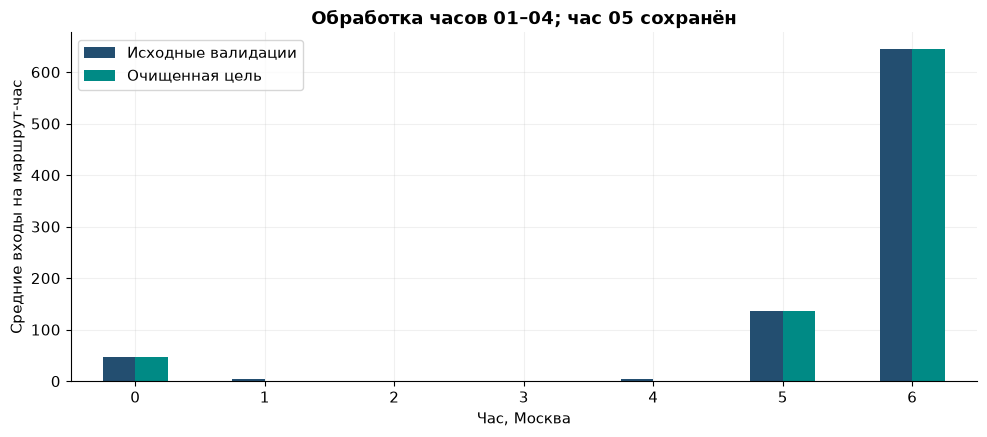

In [4]:
hourly = data.groupby("hour")[["raw_boardings", "boardings"]].mean().loc[:6]
fig, ax = plt.subplots(figsize=(10, 4.5))
hourly.rename(
    columns={"raw_boardings": "Исходные валидации", "boardings": "Очищенная цель"}
).plot.bar(ax=ax, color=[BLUE, TEAL])
ax.set(
    xlabel="Час, Москва",
    ylabel="Средние входы на маршрут-час",
    title="Обработка часов 01–04; час 05 сохранён",
)
ax.tick_params(axis="x", rotation=0)
finish(fig, "15_qna_night_policy")

## 3. Проверка коридоров неопределённости

Радиусы получены по сентябрьским ошибкам модели, обученной до сентября.
Покрытие измерено на октябре без перекалибровки по октябрьскому факту.
Для суток используется отдельная калибровка ошибки суммы, а не сумма часовых радиусов.

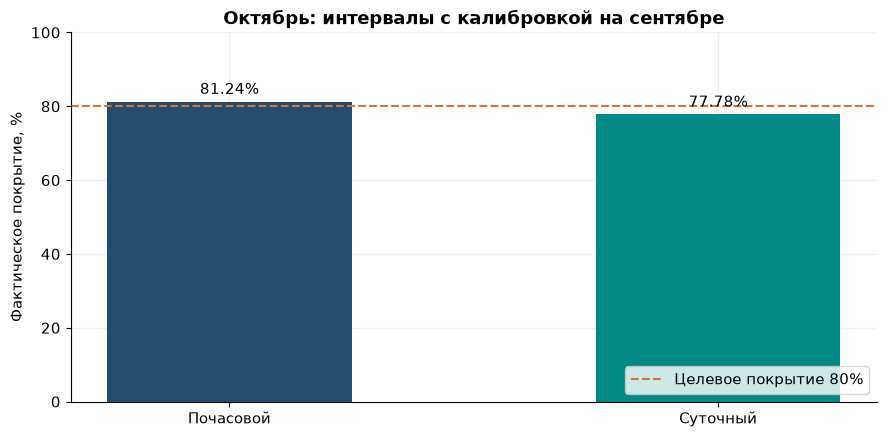

In [5]:
coverage = []
for resolution in ["hourly", "daily"]:
    rows = pd.read_csv(REPORTS / f"qna/interval_validation_{resolution}.csv", sep=";")
    assert (rows.lower >= 0).all()
    assert (rows.lower <= rows.prediction).all() and (rows.prediction <= rows.upper).all()
    actual = rows.boardings.between(rows.lower, rows.upper).mean()
    assert np.isclose(actual, metrics["intervals"][f"{resolution}_coverage"])
    coverage.append(float(actual) * 100)
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(["Почасовой", "Суточный"], coverage, color=[BLUE, TEAL], width=0.5)
ax.bar_label(bars, fmt="%.2f%%", padding=3)
ax.axhline(80, color=ORANGE, linestyle="--", label="Целевое покрытие 80%")
ax.set(
    ylim=(0, 100),
    ylabel="Фактическое покрытие, %",
    title="Октябрь: интервалы с калибровкой на сентябре",
)
ax.legend(loc="lower right")
finish(fig, "16_qna_interval_coverage")

Покрытие зависит от изменения спроса и не гарантировано на будущем периоде.
После проверки финальные радиусы пересчитаны по всему сентябрю–октябрю.

## 4. Кандидаты на восстановление провалов

Детектор использует только предыдущие аналогичные дни. В исходных данных нельзя
однозначно отличить реальное закрытие маршрута от потери регистрации валидаций.
Восстановленные значения ниже — предлагаемые оценки, а не наблюдаемый факт.

,route,date,observed,restored,analog_days,latest_analog,reason
0,50,2025-09-07,20,13337,8,2025-08-31,low_daily_volume_and_sparse_active_hours
1,50,2025-09-14,15,11003,8,2025-09-07,low_daily_volume_and_sparse_active_hours
2,50,2025-09-21,0,8504,8,2025-09-14,low_daily_volume_and_sparse_active_hours
3,50,2025-09-27,20,8218,8,2025-09-20,low_daily_volume_and_sparse_active_hours


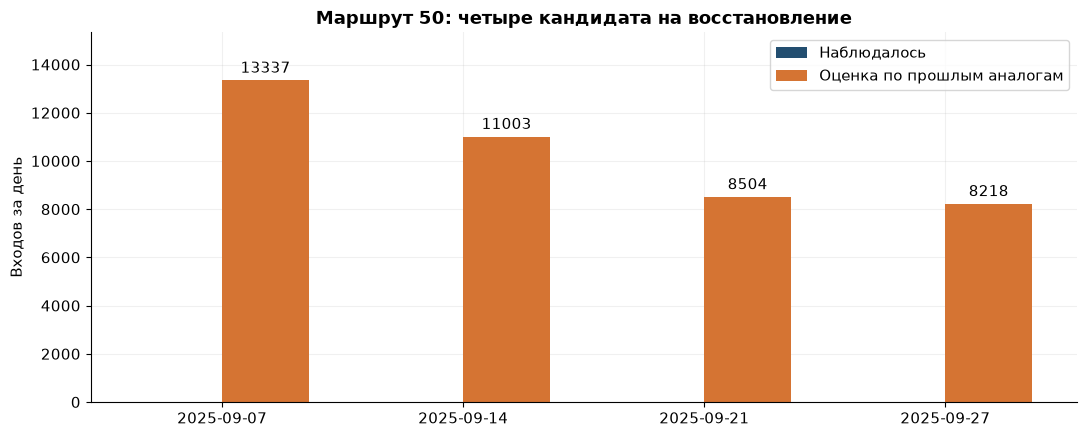

,variant,repair,candidate_gap_days,mae,wape_score
0,night_zero,False,0,148.157557,0.814773
1,night_zero_with_repair,True,0,148.157557,0.814773


In [6]:
gaps = pd.read_csv(REPORTS / "qna/full_history_gap_candidates.csv", sep=";")
assert (pd.to_datetime(gaps.latest_analog) < pd.to_datetime(gaps.date)).all()
display(gaps)
fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(gaps))
ax.bar(x - 0.18, gaps.observed, width=0.36, color=BLUE, label="Наблюдалось")
proposed = ax.bar(
    x + 0.18, gaps.restored, width=0.36, color=ORANGE, label="Оценка по прошлым аналогам"
)
ax.bar_label(proposed, padding=3)
ax.set_xticks(x, gaps.date)
ax.set(ylabel="Входов за день", title="Маршрут 50: четыре кандидата на восстановление")
ax.margins(y=0.15)
ax.legend()
finish(fig, "17_qna_gap_candidates")
assert metrics["selected"]["repair"] is False
display(pd.DataFrame(metrics["development_candidates"]))

На периоде выбора (обучение до июля, проверка июль–август) подходящих провалов
в обучении не найдено; два варианта дали одинаковый результат. Автоматическое
восстановление в основном выпуске выключено. Проверочный факт не исправляется.

Четыре внешних источника сохраняются в модели. Старые абляции относятся к старому
выпуску и не доказывают тот же прирост после новой обработки цели.
№5 не включён в интервалы и таблицу forecast; в интерфейсе его статус — «нет данных».